## SM/ML Project



# Importing modules

In [ ]:
import warnings

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


from sklearn.metrics import classification_report, confusion_matrix, r2_score


import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
import glob
%matplotlib inline

In [ ]:
label_maps={0:'E-waste',1:'Automobile Wastes',2:'Battery Waste',3:'Glass Waste',4:'Light Bulbs',5:'Metal Waste',6:'Organic Waste',7:'Paper Waste',8:'Plastic Waste'}
train_dir='/kaggle/input/custom-waste-classification-dataset/wastes/train'
test_dir='/kaggle/input/custom-waste-classification-dataset/wastes/test'
label_maps
#categories=['E-waste','Automobile Wastes','Battery Waste','Glass Waste','Light Bulbs','Metal Waste','Organic Waste','Paper Waste','Plastic Waste']


{0: 'E-waste',
 1: 'Automobile Wastes',
 2: 'Battery Waste',
 3: 'Glass Waste',
 4: 'Light Bulbs',
 5: 'Metal Waste',
 6: 'Organic Waste',
 7: 'Paper Waste',
 8: 'Plastic Waste'}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EDA

Classes found: ['test', 'train']
Image counts per class:
test: 9
train: 9


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


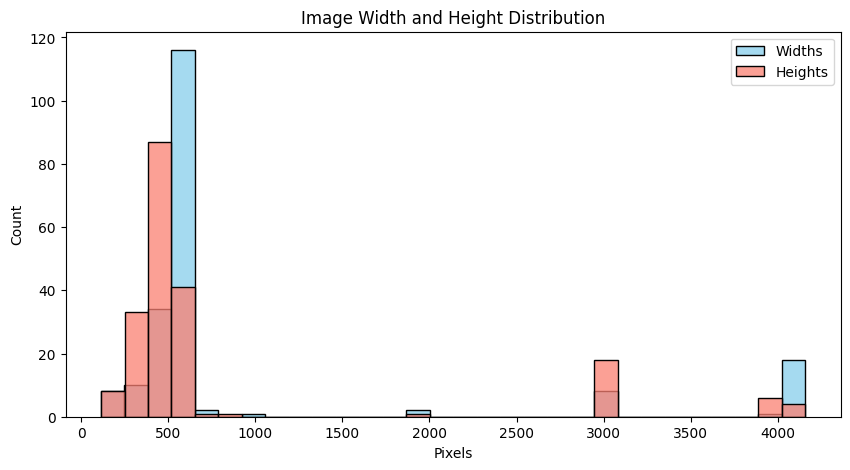

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

# Set your dataset path here
DATA_DIR = '/kaggle/input/custom-waste-classification-dataset/wastes'

# Get list of classes (folder names)
classes = os.listdir(DATA_DIR)
print(f"Classes found: {classes}")

# Count number of images per class
image_counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) for cls in classes}
print("Image counts per class:")
for cls, count in image_counts.items():
    print(f"{cls}: {count}")

# Plot class distribution


# Show sample images from each class
def show_sample_images(data_dir, classes):
    plt.figure(figsize=(15, 10))
    for idx, cls in enumerate(classes):
        class_path = os.path.join(data_dir, cls)

        # Filter out directories, keep only image files
        image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

        if not image_files:
            continue  # Skip if no images found

        image_path = os.path.join(class_path, image_files[0])
        try:
            img = Image.open(image_path)
            plt.subplot(2, 3, idx+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
        except Exception as e:
            print(f"Error opening image {image_path}: {e}")
            continue

    plt.suptitle("Sample Images from Each Class")
    plt.tight_layout()
    plt.show()


# Analyze image dimensions
def get_image_shapes(data_dir, classes, max_per_class=100):
    shapes = []

    for cls in classes:
        cls_path = os.path.join(data_dir, cls)

        count = 0
        for root, _, files in os.walk(cls_path):
            for img_name in files:
                if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(root, img_name)
                try:
                    img = Image.open(img_path)
                    shapes.append(img.size)  # (width, height)
                    count += 1
                except Exception as e:
                    print(f"Could not open {img_path}: {e}")
                    continue

                if count >= max_per_class:
                    break
            if count >= max_per_class:
                break

    return shapes


shapes = get_image_shapes(DATA_DIR, classes)
widths, heights = zip(*shapes)

# Plot image size distribution
plt.figure(figsize=(10, 5))
sns.histplot(widths, bins=30, color='skyblue', label='Widths')
sns.histplot(heights, bins=30, color='salmon', label='Heights')
plt.title("Image Width and Height Distribution")
plt.xlabel("Pixels")
plt.legend()
plt.show()



The image width and height distribution shows that most images fall within the 300–700 pixel range, indicating that the dataset primarily contains small to medium-sized images, which are suitable for deep learning models. However, there are a few outliers with very large dimensions (e.g., around 2000, 3000, and 4000+ pixels), which may need resizing to ensure consistency. The height and width distributions appear similar, suggesting that most images are nearly square or maintain consistent aspect ratios. This analysis highlights the need for resizing and normalization during preprocessing.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


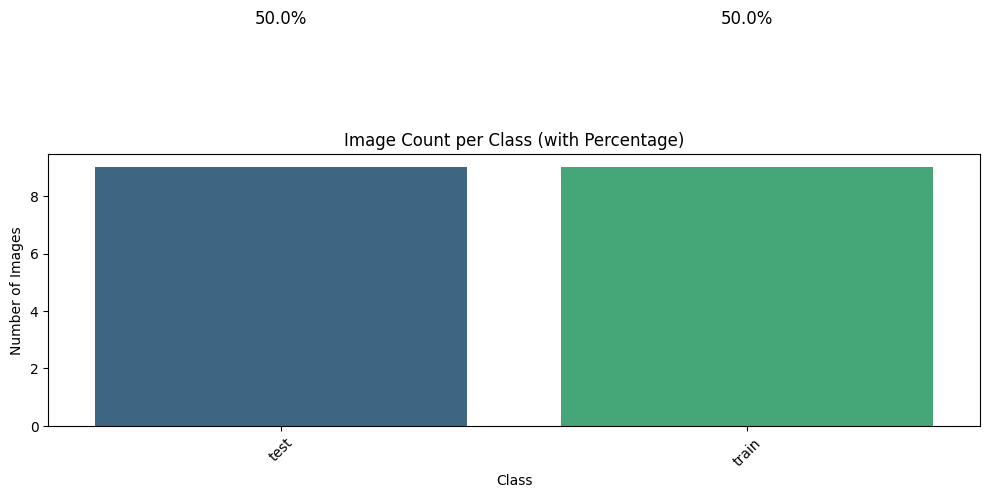

In [ ]:
# Class distribution bar chart with percentage labels
plt.figure(figsize=(10, 6))
total_images = sum(image_counts.values())
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette='viridis')

for i, count in enumerate(image_counts.values()):
    percent = (count / total_images) * 100
    plt.text(i, count + 5, f"{percent:.1f}%", ha='center', fontsize=12)

plt.title("Image Count per Class (with Percentage)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The bar chart shows that the dataset is evenly split between the **train** and **test** sets, with each containing **50% of the total images**. This balanced distribution ensures fair model evaluation and indicates that the dataset has been properly partitioned, which is important for training and validating a classification model effectively.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


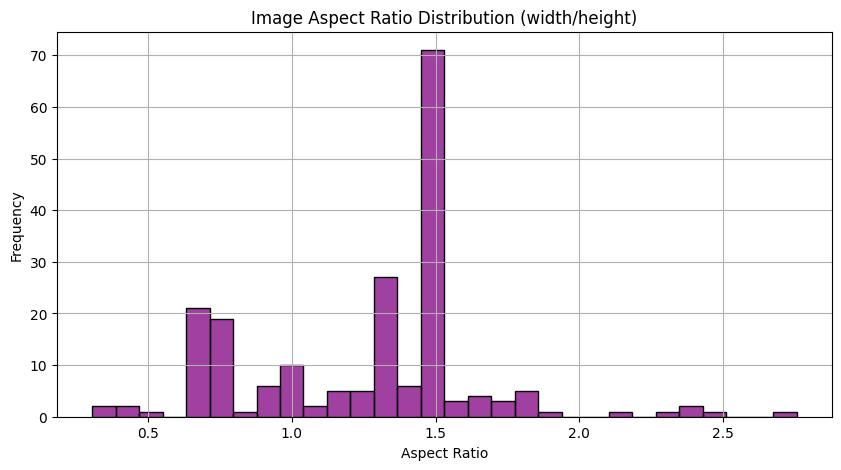

In [ ]:

if shapes:
    aspect_ratios = [w / h for (w, h) in shapes if h != 0]

    plt.figure(figsize=(10, 5))
    sns.histplot(aspect_ratios, bins=30, color='purple')
    plt.title("Image Aspect Ratio Distribution (width/height)")
    plt.xlabel("Aspect Ratio")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


The aspect ratio distribution plot reveals that most images have an aspect ratio around **1.5**, indicating a common rectangular shape. However, there is a noticeable variety, with several images having aspect ratios both less than 1 (portrait) and greater than 1.5 (wide). This diversity suggests that the dataset includes images with various orientations and dimensions, which may require resizing or normalization during preprocessing to ensure model consistency.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


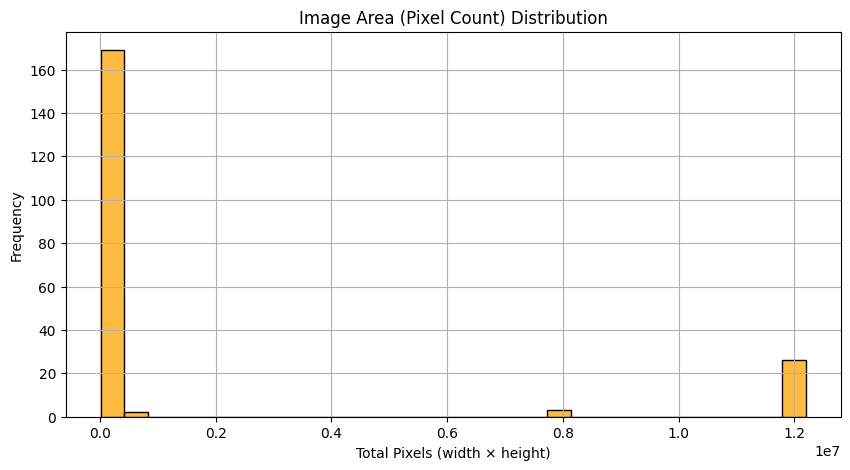

In [ ]:
if shapes:
    areas = [w * h for (w, h) in shapes]

    plt.figure(figsize=(10, 5))
    sns.histplot(areas, bins=30, color='orange')
    plt.title("Image Area (Pixel Count) Distribution")
    plt.xlabel("Total Pixels (width × height)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()


The image area (pixel count) distribution shows that the vast majority of images have a relatively small area, indicating low-resolution images are dominant in the dataset. However, there are a few high-resolution images with significantly larger pixel counts, suggesting the presence of outliers. This variation in image size may require normalization to ensure consistent input dimensions for model training.

Classes found: ['test', 'train']
Image counts per class:
test: 9
train: 9


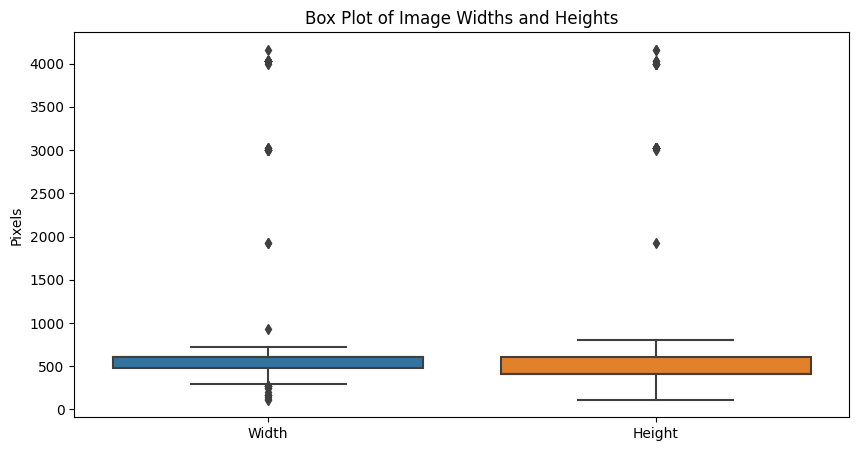

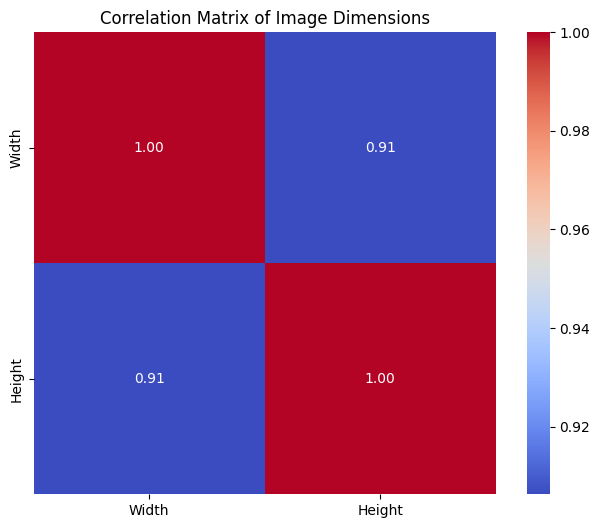

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import pandas as pd

# Set your dataset path here
DATA_DIR = '/kaggle/input/custom-waste-classification-dataset/wastes'

# Get list of classes (folder names)
classes = os.listdir(DATA_DIR)
print(f"Classes found: {classes}")

# Count number of images per class
image_counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) for cls in classes}
print("Image counts per class:")
for cls, count in image_counts.items():
    print(f"{cls}: {count}")

# Show sample images from each class
def show_sample_images(data_dir, classes):
    plt.figure(figsize=(15, 10))
    for idx, cls in enumerate(classes):
        class_path = os.path.join(data_dir, cls)

        # Filter out directories, keep only image files
        image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

        if not image_files:
            continue  # Skip if no images found

        image_path = os.path.join(class_path, image_files[0])
        try:
            img = Image.open(image_path)
            plt.subplot(2, 3, idx+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
        except Exception as e:
            print(f"Error opening image {image_path}: {e}")
            continue

    plt.suptitle("Sample Images from Each Class")
    plt.tight_layout()
    plt.show()

# Analyze image dimensions
def get_image_shapes(data_dir, classes, max_per_class=100):
    shapes = []

    for cls in classes:
        cls_path = os.path.join(data_dir, cls)

        count = 0
        for root, _, files in os.walk(cls_path):
            for img_name in files:
                if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(root, img_name)
                try:
                    img = Image.open(img_path)
                    shapes.append(img.size)  # (width, height)
                    count += 1
                except Exception as e:
                    print(f"Could not open {img_path}: {e}")
                    continue

                if count >= max_per_class:
                    break
            if count >= max_per_class:
                break

    return shapes

shapes = get_image_shapes(DATA_DIR, classes)
widths, heights = zip(*shapes)


# Create a DataFrame for box plot and correlation matrix
df = pd.DataFrame({'Width': widths, 'Height': heights})

# Box plot for image dimensions
plt.figure(figsize=(10, 5))
sns.boxplot(data=df)
plt.title("Box Plot of Image Widths and Heights")
plt.ylabel("Pixels")
plt.xticks([0, 1], ['Width', 'Height'])
plt.show()

# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Image Dimensions")
plt.show()

From the analysis, we observe that the image widths and heights vary significantly, with several outliers indicating unusually large images. The box plot shows that most images fall within a moderate range, but a few have very high pixel values. The correlation matrix reveals a strong positive correlation (0.91) between width and height, suggesting that as one increases, the other tends to increase proportionally. This implies that most images maintain a consistent aspect ratio, which can be useful for preprocessing in machine learning tasks like resizing without distorting the content.

In [ ]:
import os
class_names = os.listdir(train_dir)

for class_name in class_names:
    class_dir = os.path.join(train_dir, class_name)
    class_images = glob.glob(os.path.join(class_dir, '*.jpg'))  # Assuming .jpg files
    print(f"Number of training samples in class '{class_name}': {len(class_images)}")

Number of training samples in class 'paper waste': 1333
Number of training samples in class 'glass waste': 1018
Number of training samples in class 'organic waste': 442
Number of training samples in class 'plastic waste': 1191
Number of training samples in class 'automobile wastes': 867
Number of training samples in class 'metal waste': 1214
Number of training samples in class 'battery waste': 846
Number of training samples in class 'E-waste': 1248
Number of training samples in class 'light bulbs': 420


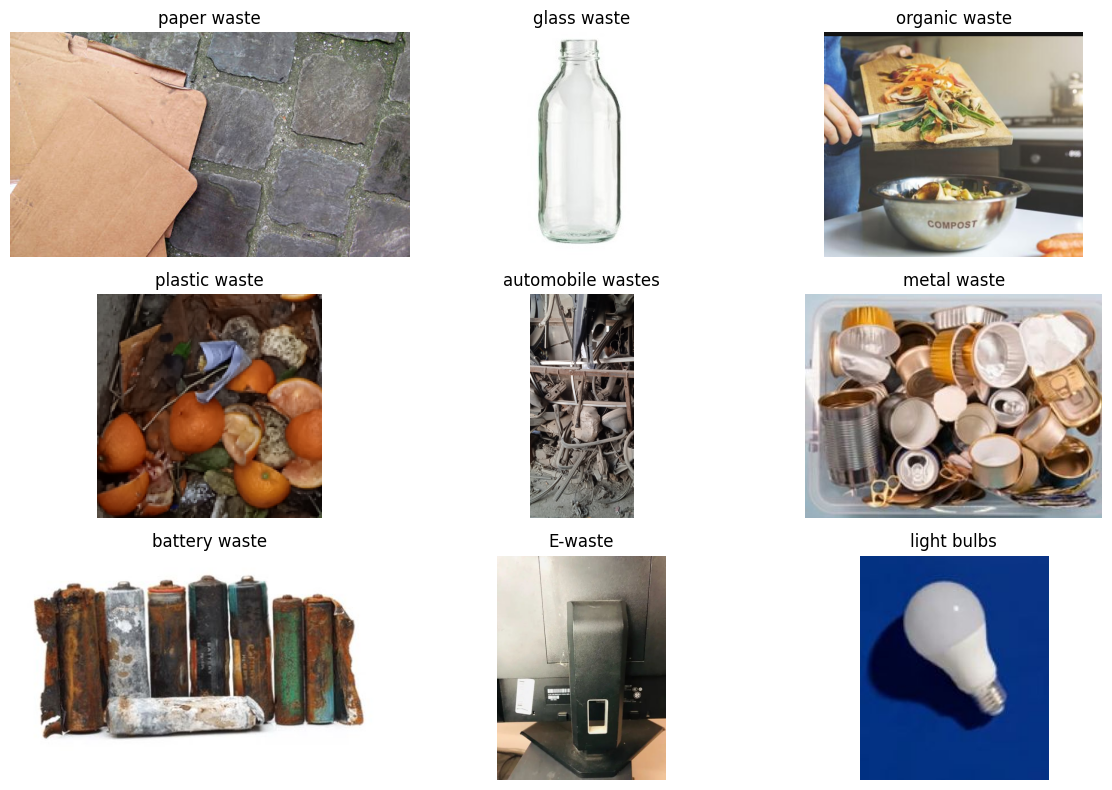

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


dataset_path = '/kaggle/input/custom-waste-classification-dataset/wastes/test'
classes = os.listdir(dataset_path)

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_dir = os.path.join(dataset_path, cls)


    img_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]

    if img_files:
        img_path = os.path.join(class_dir, img_files[0])
        img = mpimg.imread(img_path)
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 256
BASE_DIR = r"/kaggle/input/custom-waste-classification-dataset/wastes"


train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1.0/255)


train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(BASE_DIR , 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


test_generator = test_datagen.flow_from_directory(
    directory=os.path.join(BASE_DIR , 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 9214 images belonging to 9 classes.
Found 2308 images belonging to 9 classes.


In [ ]:

class_labels = train_generator.class_indices

# Print the class labels and their corresponding encoded values
print("Class Labels and Encoded Values:")
print(class_labels)

n_labels = {v: k for k, v in class_labels.items()}
print("Encoded Labels:")
print(n_labels)

Class Labels and Encoded Values:
{'E-waste': 0, 'automobile wastes': 1, 'battery waste': 2, 'glass waste': 3, 'light bulbs': 4, 'metal waste': 5, 'organic waste': 6, 'paper waste': 7, 'plastic waste': 8}
Encoded Labels:
{0: 'E-waste', 1: 'automobile wastes', 2: 'battery waste', 3: 'glass waste', 4: 'light bulbs', 5: 'metal waste', 6: 'organic waste', 7: 'paper waste', 8: 'plastic waste'}


In [ ]:
base_model = MobileNetV2(input_shape=(224, 224, 3),
                          include_top=False,
                          weights="imagenet")


for layer in base_model.layers:
    layer.trainable = False

# Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.applications import MobileNetV2

# Load the pretrained MobileNetV2 model without the top (fully connected) layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Redefining the model with reduced dense layer sizes
model = Sequential()

# Add the base model (MobileNetV2)
model.add(base_model)

# Add dropout and flatten layers
model.add(Dropout(0.2))
model.add(Flatten())


model.add(BatchNormalization())
model.add(Dense(512, activation="relu", kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(256, activation="relu", kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation="relu", kernel_initializer='he_uniform'))
model.add(Dropout(0.2))

# Final output layer with 9 classes and softmax activation
model.add(Dense(9, activation="softmax"))

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
)

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1744396359.523272     138 service.cc:148] XLA service 0x2f28b040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744396359.524063     138 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744396360.658064     138 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1744396371.548991     138 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744396371.741118     138 gpu_timer.cc:82] 

 1/36 ━━━━━━━━━━━━━━━━━━━━ 48:14 83s/step - accuracy: 0.1484 - loss: 3.3897

I0000 00:00:1744396376.576937     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/36 ━━━━━━━━━━━━━━━━━━━━ 2:54 7s/step - accuracy: 0.1955 - loss: 2.9088

E0000 00:00:1744396454.323858     138 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744396454.532976     138 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744396454.749950     138 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744396454.941912     138 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


36/36 ━━━━━━━━━━━━━━━━━━━━ 344s 7s/step - accuracy: 0.3141 - loss: 2.3489 - val_accuracy: 0.6434 - val_loss: 1.2003
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 269s 6s/step - accuracy: 0.6091 - loss: 1.1961 - val_accuracy: 0.7197 - val_loss: 0.8762
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 267s 6s/step - accuracy: 0.6628 - loss: 1.0339 - val_accuracy: 0.7535 - val_loss: 0.7527
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 266s 6s/step - accuracy: 0.6853 - loss: 0.9360 - val_accuracy: 0.7738 - val_loss: 0.7005
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 267s 6s/step - accuracy: 0.7103 - loss: 0.8661 - val_accuracy: 0.7751 - val_loss: 0.6736
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 269s 6s/step - accuracy: 0.7366 - loss: 0.7845 - val_accuracy: 0.7877 - val_loss: 0.6455
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 268s 6s/step - accuracy: 0.7536 - loss: 0.7400 - val_accuracy: 0.7920 - val_loss: 0.6379
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 265s 6s/step - accuracy: 0.7705 - loss: 0.6727 - val_accuracy: 0.7942 - val_loss: 0.

Final Model Saved as Waste_classification_final.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.8307 - loss: 0.5411
Test Accuracy: 81.72%


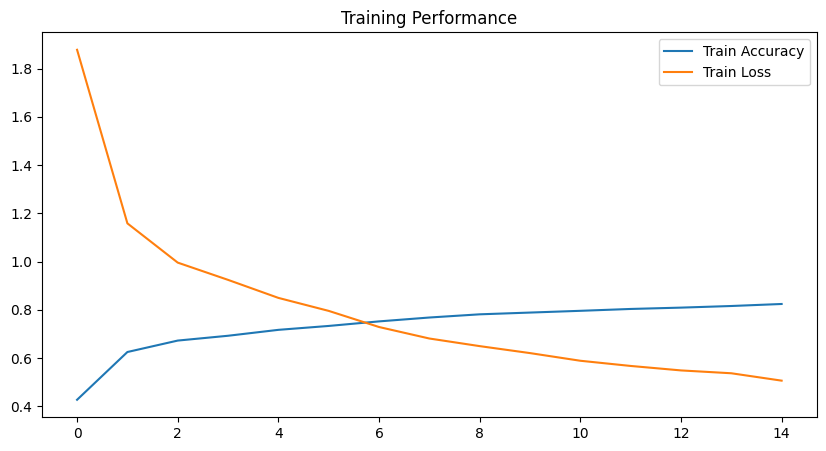

In [ ]:
# Saving the Final Model
model.save("/kaggle/working/Waste_classification_final.h5")
print("Final Model Saved as Waste_classification_final.h5")

# Evaluating the Model on Test Data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.legend()
plt.title('Training Performance')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, r2_score
import numpy as np

test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Correct usage of R2 Score (no target_names)
r2 = r2_score(y_true, y_pred_classes)

# Classification report with class labels
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes, target_names=class_labels))
print("\nR2 Score:\n", r2)


10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step

Classification Report:
                    precision    recall  f1-score   support

          E-waste       0.78      0.85      0.81       313
automobile wastes       0.79      0.86      0.83       218
    battery waste       0.86      0.78      0.82       213
      glass waste       0.81      0.78      0.80       256
      light bulbs       0.84      0.79      0.81       105
      metal waste       0.74      0.83      0.78       308
    organic waste       0.87      0.91      0.89       223
      paper waste       0.89      0.86      0.87       343
    plastic waste       0.82      0.70      0.75       329

         accuracy                           0.82      2308
        macro avg       0.82      0.82      0.82      2308
     weighted avg       0.82      0.82      0.82      2308


R2 Score:
 0.620800863075067


# Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


Text(0.5, 1.0, 'Actual Class: Plastic\nPredicted Class: plastic waste')

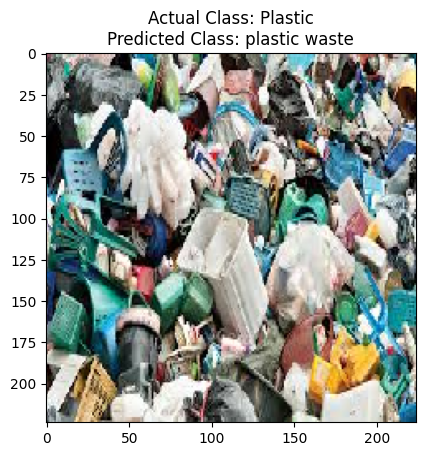

In [ ]:
# Load the trained model
#model = load_model('/kaggle/working/Waste_classification.h5')


IMG_SIZE = (224, 224)

img_path = r"/kaggle/input/plastic/download.jpeg"


img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


predictions = model.predict(img_array)


predicted_class_index = np.argmax(predictions, axis=1)[0]


train_dir = r"/kaggle/input/custom-waste-classification-dataset/wastes/train"
class_labels = sorted(os.listdir(train_dir))


predicted_class = class_labels[predicted_class_index]

'''# Output the prediction
print(f"Predicted class: {predicted_class}")

# Display the image
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()'''

plt.imshow(img)
plt.title(f'Actual Class: Plastic\nPredicted Class: {predicted_class}')

In [ ]:
model = load_model('/content/drive/MyDrive/archive/Waste_classification.h5')


NameError: name 'load_model' is not defined

# Deployment


2vZYYGKN0uz8tKLkGV6FUnVgSlK_3nTvjh3qfFrfshq9QkE6S

In [ ]:
!pip install streamlit opencv-python-headless tensorflow ngrok mtcnn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.9 MB/s eta 0:00:00


In [ ]:
pip install pyngrok

In [ ]:
!ngrok authtoken 2uzMZQgddAJnJwliNEmXnFmY9LE_3v4c8RqyUhSwqM1BzYmU5

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
#!streamlit run app.py

In [ ]:
import os
import subprocess
from pyngrok import ngrok

# List existing tunnels and kill them
active_tunnels = ngrok.get_tunnels()
for tunnel in active_tunnels:
    print(f"Killing tunnel: {tunnel.public_url}")
    ngrok.disconnect(tunnel.public_url)

# Start Streamlit in the background
subprocess.Popen(["streamlit", "run", "app.py"])

# Open a tunnel on port 8501
public_url = ngrok.connect(8501, "http")
print("Streamlit app is running at:", public_url)

Killing tunnel: https://6348-35-204-64-81.ngrok-free.app
Streamlit app is running at: NgrokTunnel: "https://ea31-35-204-64-81.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import os
from keras.models import load_model
from keras.preprocessing import image
from PIL import Image
import matplotlib.pyplot as plt

model = load_model('/content/drive/MyDrive/archive/Waste_classification.h5')

IMG_SIZE = (224, 224)
class_labels = ['E-waste','Automobile Wastes','Battery Waste','Glass Waste','Light Bulbs','Metal Waste','Organic Waste','Paper Waste','Plastic Waste']

# Streamlit App
st.set_page_config(page_title="Waste Classification", layout="centered")
st.title("♻️ Waste Classification Model")
st.write("Upload an image of waste to classify it.")

# Image upload
uploaded_file = st.file_uploader("Choose a waste image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display uploaded image
    image_pil = Image.open(uploaded_file)
    st.image(image_pil, caption="Uploaded Image", use_column_width=True)

    # Preprocess the image
    img = image_pil.resize(IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    st.write("Preprocessed image shape:", img_array.shape)

    # Make prediction
    predictions = model.predict(img_array)
    st.write("Raw model predictions:", predictions)

    predicted_class_index = np.argmax(predictions, axis=1)[0]
    st.write("Predicted class index:", predicted_class_index)

    try:
        predicted_class = class_labels[predicted_class_index]
        st.success(f"Predicted Class: **{predicted_class}**")
    except IndexError:
        st.error(f"Prediction index {predicted_class_index} is out of range for class_labels.")


Overwriting app.py
